In [6]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
column_names = [
    "age",
    "sex",
    "height",
    "weight",
    "qrsduration",
    "printerval",
    "qtinterval",
    "tinterval",
    "pinterval",
    "qrs",
    "t",
    "p",
    "qrst",
    "j",
    "heartrate",
]

for i in ["q", "r", "s", "r1", "s1"]:
    column_names.append("di_"+i)

column_names.append("num_intrisic_deflections")

column_names.append("ragged_r")
column_names.append("diphasic_r")

column_names.append("ragged_p")
column_names.append("diphasic_p")

column_names.append("ragged_t")
column_names.append("diphasic_t")

for i in range(28, 280):
    column_names.append(f"channel_{i}")

column_names.append('target')

In [4]:
data = pd.read_csv('../benchmark/data/arrhythmia/arrhythmia.data', header=None, names=column_names)

In [5]:
data.head()

,age,sex,height,weight,qrsduration,printerval,qtinterval,tinterval,pinterval,qrs,...,channel_271,channel_272,channel_273,channel_274,channel_275,channel_276,channel_277,channel_278,channel_279,target
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7


In [7]:
data = data.replace("?", np.nan)

In [10]:
for i in data.isna().sum():
    print(i)

0
0
0
0
0
0
0
0
0
0
8
22
1
376
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


<Axes: xlabel='target'>

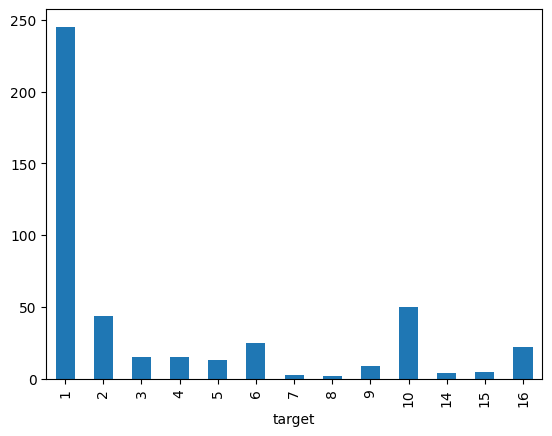

In [ ]:
res = data["target"].value_counts().sort_index()
res.plot(kind="bar")

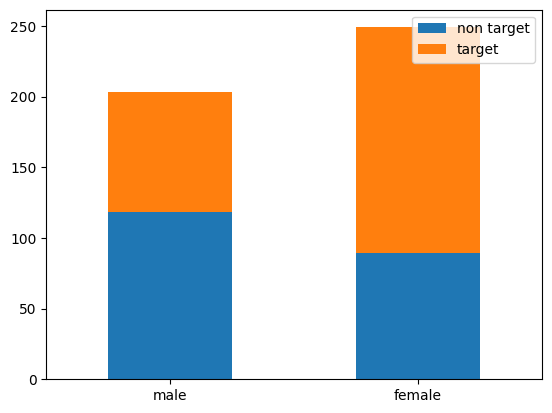

In [11]:
target = data[data['target'] == 1]
man_target = len(target[target['sex'] == 0].index)
woman_target = len(target[target['sex'] == 1].index)

non_target = data[data['target'] != 1]
man_non_target = len(non_target[non_target['sex'] == 0].index)
woman_non_target = len(non_target[non_target['sex'] == 1].index)


res_df = pd.DataFrame(
    {
        'non target': [man_non_target, woman_non_target],
        'target': [man_target, woman_target],
    },
    index=['male', 'female']
)

res_df.plot(kind='bar', stacked=True)#, color=['red', 'pink'])
plt.legend(loc="upper right")
plt.xticks(rotation=0)
plt.show()

<Axes: >

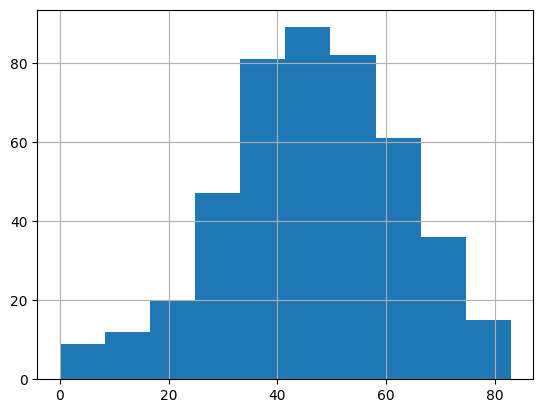

In [ ]:
data["age"].hist()

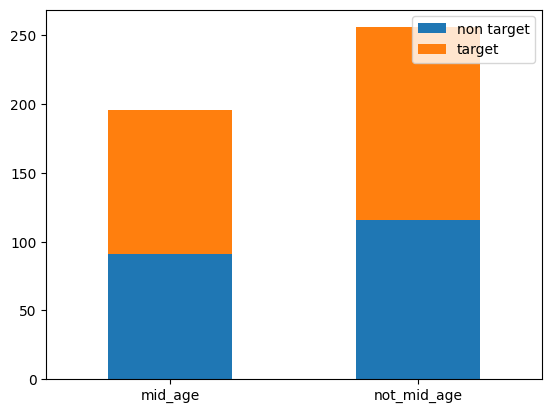

In [20]:
target = data[data['target'] == 1]
mid_age_target = len(target[(target['age'] >= 45) & (target['age'] <= 65)].index)
non_mid_agetarget = len(target[(target['age'] < 45) | (target['age'] > 65)].index)

non_target = data[data['target'] != 1]
mid_age_non_target = len(non_target[(non_target['age'] >= 45) & (non_target['age'] <= 65)].index)
non_mid_agenon_target = len(non_target[(non_target['age'] < 45) | (non_target['age'] > 65)].index)


res_df = pd.DataFrame(
    {
        'non target': [mid_age_non_target, non_mid_agenon_target],
        'target': [mid_age_target, non_mid_agetarget],
    },
    index=['mid_age', 'not_mid_age']
)

res_df.plot(kind='bar', stacked=True)#, color=['red', 'pink'])
plt.legend(loc="upper right")
plt.xticks(rotation=0)
plt.show()